# Feature selection Complexity evaluation (including univariate ranking): Artificial datasets

In [1]:
import pandas as pd
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re



In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

In [3]:
# # Cargar la tabla de comparación del dataset
# comparison_table = pd.read_csv("Results_FS_ComplexityEvaluation_WithUnivariate/ArtificialDataset1_comparisonTable.csv", index_col=[1])
#
# display(comparison_table.iloc[:,1:].style.background_gradient(cmap="viridis"))

In [4]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_FS_ComplexityEvaluation_WithUnivariate/*_comparisonTable.csv")

all_tables = []
for f in files:
    df = pd.read_csv(f, index_col=[1])
    all_tables.append(df)

comparison_all = pd.concat(all_tables)
comparison_all.head()


,Dataset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,...,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset13,0.208333,0.299400,0.282408,0.616070,0.461125,0.271384,0.489051,0.997882,0.997806,...,0.865212,0.997978,0.386755,115.0,0.724458,0.839667,0.089735,0.708086,0.831392,0.092533
informative,ArtificialDataset13,0.154667,0.258200,0.321204,0.590860,0.452713,0.232287,0.477267,0.997368,0.997920,...,0.893540,0.992335,0.370419,25.0,0.754208,0.874333,0.089601,0.735076,0.869020,0.100875
informative+redundant,ArtificialDataset13,0.171667,0.274800,0.315869,0.582250,0.443240,0.253413,0.478939,0.997515,0.997667,...,0.893379,0.996313,0.201528,55.0,0.747375,0.871000,0.088970,0.730592,0.865443,0.097969
informative+redundant_nonLinear,ArtificialDataset13,0.182000,0.282733,0.292341,0.507290,0.469100,0.246660,0.480586,0.997669,0.997873,...,0.835060,0.994706,0.312593,55.0,0.728167,0.855333,0.110425,0.708809,0.848530,0.120258
informative+noise,ArtificialDataset13,0.240333,0.364133,0.305211,0.562383,0.455043,0.331338,0.493723,0.998632,0.997982,...,0.892950,0.996361,0.385616,55.0,0.717792,0.810667,0.061600,0.695234,0.799405,0.068320


## Artificial Dataset 1

- Nº muestras: 1000
- Características: 10 informativas, 2 ruido, 4 redundantes lineales, 2 redundantes no lineales --> 18 en total
- Separabilidad (class_sep): 1 (alta)
- Ruido en etiquetas (flip_y): 0
- Clusters/clase: 1
- Balance de clases: [0.5, 0.5] (equilibrado)
- Ruido adicional (noise_std): 0.01

In [5]:
# comparison_all.loc['ArtificialDataset1']
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset1'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.046000,0.069000,0.044942,0.612727,0.147362,0.051942,0.401273,0.958403,0.976333,0.704036,0.867668,0.984676,0.739084,18.000000,0.954250,0.986000,0.032801,0.954245,0.986000,0.032808
informative,0.035000,0.051000,0.016597,0.599091,0.146010,0.033283,0.373701,0.944228,0.974700,0.719968,0.865999,0.975724,0.695393,10.000000,0.957750,0.990000,0.032849,0.957746,0.990000,0.032855
informative+redundant,0.037000,0.052800,0.010725,0.613545,0.160466,0.033117,0.372744,0.944631,0.971643,0.711289,0.864069,0.979513,0.797456,14.000000,0.954000,0.988000,0.035569,0.953998,0.988000,0.035571
informative+redundant_nonLinear,0.034000,0.060800,0.016597,0.599364,0.141838,0.039467,0.379799,0.955178,0.977250,0.717094,0.867485,0.978530,0.661763,12.000000,0.954750,0.989000,0.035808,0.954749,0.988999,0.035809
informative+noise,0.042000,0.066400,0.098407,0.550667,0.141574,0.043424,0.407718,0.962517,0.978167,0.714058,0.869268,0.980667,0.664564,12.000000,0.953625,0.985000,0.034924,0.953623,0.985000,0.034926
informative+rand_extra,0.041000,0.060600,0.009774,0.607455,0.164299,0.047826,0.390360,0.950563,0.972231,0.708597,0.864234,0.980645,0.722216,13.000000,0.955500,0.987000,0.031861,0.955498,0.987000,0.031865
mutual_info_top10,0.064000,0.089200,0.117013,0.546615,0.169743,0.087900,0.362421,0.953158,0.963900,0.723068,0.859115,0.968786,0.061728,10.000000,0.928875,0.955000,0.028762,0.928861,0.954992,0.028764
f_classif_top10,0.072000,0.103600,0.063668,0.552083,0.168073,0.098893,0.382324,0.950649,0.966300,0.719952,0.860541,0.974886,0.759174,10.000000,0.927625,0.960000,0.025467,0.927620,0.959994,0.025464
rf_top10,0.048000,0.067400,0.046560,0.764444,0.156921,0.060602,0.353386,0.921090,0.964200,0.715663,0.859058,0.970807,0.090498,10.000000,0.935750,0.973000,0.029256,0.935748,0.972997,0.029255


## Artificial Dataset 2

 - Nº muestras: 1000
 - Características: 10 informativas, 2 ruido, 4 redundantes lineales, 2 redundantes no lineales --> 18 en total
 - Separabilidad (class_sep): 0.6 (más difícil de separar)
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.01

In [6]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset2'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.096000,0.130800,0.102014,0.671750,0.247673,0.101082,0.423927,0.976896,0.984222,0.721419,0.872538,0.985340,0.483732,18.000000,0.895750,0.963000,0.051294,0.895730,0.962995,0.051308
informative,0.078000,0.107400,0.088088,0.593333,0.249648,0.067752,0.402904,0.971353,0.983600,0.736686,0.871632,0.976561,0.422721,10.000000,0.903375,0.977000,0.059416,0.903366,0.976999,0.059420
informative+redundant,0.081000,0.115200,0.105041,0.647500,0.264310,0.094810,0.402504,0.971571,0.982000,0.731331,0.870439,0.979993,0.470010,14.000000,0.897125,0.971000,0.059415,0.897103,0.970998,0.059435
informative+redundant_nonLinear,0.069000,0.111200,0.023133,0.650182,0.245998,0.084667,0.404127,0.974451,0.984417,0.732196,0.872052,0.979471,0.428464,12.000000,0.900875,0.971000,0.055743,0.900862,0.970999,0.055753
informative+noise,0.105000,0.137400,0.088088,0.597500,0.245478,0.090355,0.429860,0.979780,0.985583,0.729550,0.873962,0.981229,0.450263,12.000000,0.897625,0.965000,0.053926,0.897616,0.964998,0.053928
informative+rand_extra,0.090000,0.126400,0.137654,0.598923,0.265848,0.096774,0.418381,0.976110,0.983154,0.727740,0.870821,0.981649,0.470098,13.000000,0.893500,0.963000,0.057582,0.893488,0.962994,0.057585
mutual_info_top10,0.114000,0.179200,0.144307,0.399286,0.277373,0.164100,0.411188,0.981062,0.978300,0.746638,0.868398,0.970133,0.141435,10.000000,0.856000,0.909000,0.043504,0.855905,0.908927,0.043511
f_classif_top10,0.131000,0.191400,0.195597,0.574923,0.282936,0.178617,0.422653,0.978922,0.980500,0.740931,0.869307,0.976421,0.508600,10.000000,0.847125,0.898000,0.039873,0.847060,0.897869,0.039842
rf_top10,0.096000,0.128000,0.065991,0.634333,0.258633,0.110783,0.390631,0.961844,0.978300,0.738574,0.867745,0.972474,0.057537,10.000000,0.873500,0.933000,0.051119,0.873467,0.932996,0.051144


## Artificial Dataset 3

 - Nº muestras: 1000
 - Características: 25 informativas, 5 ruido, 7 redundantes lineales, 8 redundantes no lineales --> 45 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.05

In [7]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset3'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.050000,0.095000,0.128174,0.649000,0.161818,0.063008,0.458697,0.977972,0.989133,0.653822,0.857986,0.994525,1.132809,45.000000,0.933875,0.985000,0.050456,0.933844,0.984999,0.050502
informative,0.056000,0.076800,0.004889,0.652923,0.140096,0.037496,0.445379,0.968942,0.986720,0.698393,0.875235,0.991102,0.818155,25.000000,0.942500,0.993000,0.046736,0.942483,0.993000,0.046767
informative+redundant,0.043000,0.076600,0.007771,0.662077,0.129405,0.050861,0.445285,0.969741,0.987688,0.696884,0.876708,0.992858,1.033983,32.000000,0.942500,0.992000,0.046944,0.942471,0.992000,0.046993
informative+redundant_nonLinear,0.042000,0.084600,0.065883,0.643846,0.178253,0.049119,0.449176,0.974485,0.988182,0.654688,0.849278,0.992083,0.838673,33.000000,0.937125,0.988000,0.048994,0.937117,0.988000,0.049005
informative+noise,0.070000,0.100400,0.067468,0.653308,0.141118,0.072137,0.459966,0.977409,0.987700,0.693658,0.876343,0.992823,0.815994,30.000000,0.937500,0.987000,0.049659,0.937490,0.987000,0.049679
informative+rand_extra,0.049000,0.081200,0.087372,0.630462,0.149967,0.051504,0.449929,0.973543,0.987464,0.683756,0.870369,0.991804,0.835489,28.000000,0.938875,0.992000,0.048117,0.938850,0.992000,0.048165
mutual_info_top25,0.071000,0.105000,0.086882,0.628385,0.176572,0.088723,0.443005,0.969790,0.986640,0.662457,0.861231,0.990271,1.020301,25.000000,0.929375,0.972000,0.044055,0.929107,0.971993,0.044546
f_classif_top25,0.101000,0.134400,0.104078,0.607385,0.186626,0.097306,0.447587,0.975521,0.986480,0.662781,0.856576,0.989499,1.178811,25.000000,0.913000,0.956000,0.042068,0.912625,0.955995,0.042744
rf_top25,0.057000,0.093200,0.088500,0.640308,0.148828,0.078495,0.436126,0.967896,0.985840,0.657164,0.858359,0.989982,0.993947,25.000000,0.936625,0.981000,0.041165,0.936605,0.980999,0.041182


## Artificial Dataset 4

 - Nº muestras: 5000
 - Características: 15 informativas, 15 ruido, 4 redundantes lineales, 5 redundantes no lineales --> 39 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.01

In [8]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset4'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.049800,0.070160,0.061348,0.649278,0.128213,0.059911,0.452568,0.985685,0.995646,0.665073,0.880656,0.994655,1.083885,39.000000,0.955275,0.983400,0.026073,0.955271,0.983400,0.026075
informative,0.017000,0.026120,0.068687,0.607129,0.111095,0.019746,0.390056,0.966053,0.994013,0.741939,0.885141,0.986559,0.934909,15.000000,0.961325,0.992200,0.029182,0.961321,0.992200,0.029185
informative+redundant,0.016800,0.030680,0.061911,0.643000,0.118338,0.023062,0.388716,0.962306,0.993589,0.735442,0.884677,0.988907,0.990849,19.000000,0.961150,0.992600,0.029295,0.961145,0.992600,0.029299
informative+redundant_nonLinear,0.021800,0.031240,0.065157,0.646587,0.155103,0.024115,0.394368,0.970191,0.993920,0.666060,0.866434,0.988389,0.957598,20.000000,0.957700,0.991200,0.033881,0.957694,0.991200,0.033888
informative+noise,0.059400,0.090800,0.070670,0.646424,0.110685,0.073674,0.462659,0.992850,0.996467,0.725227,0.892075,0.993689,0.938998,30.000000,0.955100,0.983000,0.026550,0.955097,0.982999,0.026550
informative+rand_extra,0.024600,0.034200,0.070708,0.606929,0.114356,0.027738,0.410469,0.976134,0.994856,0.706879,0.878676,0.988469,0.937562,18.000000,0.960550,0.990000,0.027925,0.960548,0.990000,0.027926
mutual_info_top15,0.046400,0.066560,0.079997,0.722587,0.119996,0.062341,0.389275,0.967097,0.990800,0.740404,0.879511,0.985028,1.251778,15.000000,0.941450,0.970000,0.023404,0.941445,0.970000,0.023408
f_classif_top15,0.062200,0.077280,0.084609,0.601633,0.129702,0.067798,0.398830,0.972045,0.991813,0.707508,0.870785,0.984314,1.199256,15.000000,0.936975,0.963800,0.021530,0.936970,0.963800,0.021535
rf_top15,0.035800,0.053640,0.073599,0.702027,0.123432,0.051235,0.381671,0.959663,0.991053,0.742203,0.880024,0.984960,1.108612,15.000000,0.947250,0.979000,0.025886,0.947245,0.979000,0.025892


## Artificial Dataset 5

 - Nº muestras: 5000
 - Características: 25 informativas, 15 ruido, 8 redundantes lineales, 7 redundantes no lineales --> 55 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.05

In [9]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset5'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.038800,0.062680,0.076199,0.600337,0.153095,0.042864,0.462467,0.991262,0.996327,0.662796,0.882355,0.996021,1.102592,55.000000,0.956150,0.997000,0.047486,0.955976,0.997000,0.047824
informative,0.017000,0.026640,0.074001,0.733243,0.101268,0.017326,0.430886,0.981555,0.994920,0.723477,0.887798,0.991894,0.967018,25.000000,0.966700,0.998000,0.036537,0.966697,0.998000,0.036541
informative+redundant,0.015800,0.035360,0.075276,0.697360,0.124307,0.020803,0.434310,0.984964,0.995352,0.720145,0.888191,0.993555,0.309456,33.000000,0.964725,0.998000,0.038036,0.964716,0.998000,0.038048
informative+redundant_nonLinear,0.013000,0.029800,0.071182,0.650600,0.142710,0.018385,0.431677,0.982626,0.995088,0.663334,0.873852,0.992984,0.990231,32.000000,0.959100,0.997800,0.047388,0.958911,0.997800,0.047769
informative+noise,0.048800,0.079920,0.071905,0.711787,0.102473,0.057720,0.467393,0.993351,0.996365,0.713428,0.891146,0.994952,0.929800,40.000000,0.962775,0.996000,0.036686,0.962772,0.996000,0.036690
informative+rand_extra,0.019600,0.033360,0.073412,0.648338,0.105252,0.022366,0.439158,0.984255,0.994886,0.721354,0.887875,0.992692,0.941451,28.000000,0.965800,0.998400,0.036815,0.965795,0.998400,0.036820
mutual_info_top25,0.037200,0.056320,0.080693,0.626282,0.148583,0.044140,0.426382,0.980678,0.993408,0.664791,0.874320,0.990686,1.086030,25.000000,0.950725,0.991800,0.044247,0.950555,0.991800,0.044564
f_classif_top25,0.035800,0.063600,0.082577,0.629271,0.149616,0.051768,0.433282,0.981887,0.993432,0.664801,0.874220,0.990733,1.092753,25.000000,0.949250,0.989200,0.043414,0.949078,0.989200,0.043731
rf_top25,0.019400,0.035360,0.077393,0.720707,0.149361,0.026423,0.416753,0.976349,0.993472,0.664825,0.874165,0.990510,1.089098,25.000000,0.956450,0.995000,0.044899,0.956278,0.995000,0.045243


## Artificial Dataset 6

 - Nº muestras: 10000
 - Características: 8 informativas, 15 ruido, 4 redundantes lineales, 5 redundantes no lineales --> 32 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.01

In [10]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset6'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.042000,0.045540,0.019571,0.539112,0.163894,0.042633,0.438984,0.989105,0.990556,0.661988,0.871370,0.993229,1.105523,32.000000,0.975025,0.998500,0.050839,0.974634,0.998500,0.051932
informative,0.003300,0.004500,0.036050,0.675800,0.033655,0.003812,0.268677,0.924672,0.989012,0.756978,0.882103,0.975725,0.995970,8.000000,0.992050,0.998900,0.011268,0.992047,0.998900,0.011274
informative+redundant,0.002900,0.006820,0.021824,0.623486,0.087090,0.006123,0.281365,0.949669,0.986542,0.745244,0.880973,0.981854,1.066840,12.000000,0.988738,0.998900,0.019895,0.988732,0.998900,0.019910
informative+redundant_nonLinear,0.003500,0.005880,0.022836,0.517460,0.225900,0.005290,0.275360,0.930583,0.983100,0.663724,0.833388,0.978031,0.925287,13.000000,0.966325,0.998800,0.083543,0.964185,0.998800,0.089587
informative+noise,0.046300,0.065580,0.036050,0.617800,0.033540,0.053962,0.454241,0.995771,0.995791,0.735549,0.895294,0.992098,1.008324,23.000000,0.988437,0.998500,0.012236,0.988435,0.998500,0.012240
informative+rand_extra,0.004600,0.009640,0.035588,0.680907,0.050519,0.009163,0.331907,0.956025,0.991564,0.750993,0.885627,0.982092,1.021133,11.000000,0.990625,0.999000,0.013518,0.990622,0.999000,0.013527
mutual_info_top8,0.004600,0.010300,0.018745,0.488619,0.125156,0.010020,0.233979,0.932995,0.971812,0.669818,0.846378,0.968997,1.087621,8.000000,0.982825,0.997400,0.032819,0.982772,0.997400,0.032968
f_classif_top8,0.004400,0.011880,0.025402,0.564700,0.092510,0.011150,0.242529,0.946513,0.979900,0.749341,0.869480,0.971115,1.119859,8.000000,0.986437,0.997300,0.020748,0.986433,0.997300,0.020759
rf_top8,0.006200,0.009360,0.020400,0.516887,0.171932,0.007537,0.223606,0.924971,0.964950,0.662426,0.821066,0.959933,0.939082,8.000000,0.967912,0.997300,0.075771,0.966300,0.997300,0.080327


## Artificial Dataset 7

 - Nº muestras: 1000
 - Características: 20 informativas, 10 ruido, 10 redundantes lineales, 10 redundantes no lineales --> 50 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.05

In [11]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset7'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.027000,0.054400,0.052702,0.690917,0.148801,0.037635,0.445946,0.958892,0.986120,0.650631,0.850253,0.994314,1.312835,50.000000,0.965500,0.994000,0.033848,0.965497,0.994000,0.033852
informative,0.008000,0.027200,0.047885,0.740700,0.067308,0.018279,0.411489,0.931018,0.981650,0.693875,0.869355,0.987945,1.009091,20.000000,0.973875,0.999000,0.031466,0.973874,0.999000,0.031466
informative+redundant,0.014000,0.033000,0.011744,0.701182,0.097685,0.020969,0.413391,0.940088,0.983067,0.691234,0.870977,0.991124,1.082760,30.000000,0.970375,1.000000,0.036485,0.970373,1.000000,0.036487
informative+redundant_nonLinear,0.015000,0.032000,0.049770,0.747700,0.137310,0.018700,0.416961,0.940200,0.983367,0.651797,0.831703,0.989238,1.199497,30.000000,0.969500,0.996000,0.032413,0.969498,0.996000,0.032415
informative+noise,0.049000,0.062200,0.051221,0.658154,0.069280,0.048519,0.453899,0.968383,0.985967,0.684449,0.873547,0.992517,1.013354,30.000000,0.971500,0.997000,0.029809,0.971499,0.997000,0.029809
informative+rand_extra,0.008000,0.031200,0.042871,0.714091,0.072162,0.020702,0.419714,0.941798,0.982391,0.680967,0.863932,0.989045,1.141526,23.000000,0.973500,0.999000,0.030905,0.973499,0.999000,0.030907
mutual_info_top20,0.022000,0.043200,0.043262,0.753600,0.144102,0.038703,0.393945,0.928998,0.976150,0.654834,0.842999,0.983801,0.917458,20.000000,0.960375,0.989000,0.040352,0.960286,0.989000,0.040514
f_classif_top20,0.024000,0.046400,0.003902,0.725600,0.093106,0.039335,0.396194,0.933647,0.976600,0.687038,0.856936,0.984628,0.914243,20.000000,0.966875,0.990000,0.032982,0.966872,0.990000,0.032985
rf_top20,0.023000,0.035000,0.047594,0.746100,0.129881,0.033210,0.391093,0.930719,0.976550,0.664318,0.853581,0.984194,1.148835,20.000000,0.963750,0.995000,0.039741,0.963672,0.995000,0.039874


## Artificial Dataset 8

 - Nº muestras: 1000
 - Características: 40 informativas, 15 ruido, 15 redundantes lineales, 15 redundantes no lineales --> 85 en total
 - Separabilidad: 1
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.1

In [12]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset8'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.129000,0.184000,0.195545,0.660833,0.290143,0.124608,0.478911,0.987986,0.991871,0.654001,0.862779,0.996974,0.539881,85.000000,0.871000,0.962000,0.070488,0.870951,0.961984,0.070473
informative,0.053000,0.128000,0.206128,0.616000,0.224660,0.091075,0.468715,0.983293,0.991350,0.691204,0.877313,0.994207,0.788417,40.000000,0.885875,0.985000,0.085678,0.885827,0.984999,0.085693
informative+redundant,0.068000,0.152000,0.160299,0.635000,0.259886,0.101738,0.469315,0.984918,0.991400,0.686930,0.877493,0.995635,0.218165,55.000000,0.882000,0.981000,0.074187,0.881941,0.980999,0.074227
informative+redundant_nonLinear,0.108000,0.142000,0.193916,0.657929,0.282043,0.095126,0.470209,0.984890,0.991455,0.656383,0.853420,0.994937,0.665166,55.000000,0.888500,0.983000,0.073807,0.888484,0.982998,0.073802
informative+noise,0.120000,0.180800,0.206128,0.616214,0.225714,0.118507,0.480132,0.989130,0.992000,0.681794,0.878565,0.995885,0.798303,55.000000,0.875250,0.969000,0.076701,0.875194,0.968993,0.076714
informative+rand_extra,0.071000,0.131200,0.206128,0.615857,0.251437,0.086931,0.469220,0.983671,0.991442,0.659950,0.872450,0.994397,0.804831,43.000000,0.880125,0.984000,0.088850,0.878906,0.983998,0.090490
mutual_info_top40,0.171000,0.224400,0.146686,0.717000,0.285754,0.189818,0.472984,0.987705,0.990525,0.657237,0.854478,0.992972,0.103143,40.000000,0.854625,0.915000,0.054356,0.854511,0.914899,0.054323
f_classif_top40,0.166000,0.218000,0.181005,0.517067,0.295342,0.191840,0.472983,0.987842,0.991000,0.658035,0.857843,0.992989,0.996513,40.000000,0.847375,0.918000,0.054560,0.847032,0.917940,0.054817
rf_top40,0.119000,0.182400,0.084212,0.599923,0.290086,0.150197,0.467276,0.984910,0.990300,0.657378,0.852539,0.992700,0.975738,40.000000,0.867875,0.941000,0.060563,0.867771,0.940972,0.060542


## Artificial Dataset 9

 - Nº muestras: 3000
 - Características: 10 informativas, 20 ruido, 20 redundantes lineales, 20 redundantes no lineales --> 70 en total
 - Separabilidad: 0.7 (moderada)
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.5, 0.5]
 - Ruido adicional: 0.3

In [13]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset9'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.122333,0.124800,0.115908,0.467111,0.353002,0.100735,0.456456,0.987934,0.992171,0.660942,0.852859,0.995998,0.663266,70.000000,0.891042,0.964667,0.072675,0.890269,0.964666,0.074425
informative,0.043333,0.068600,0.070806,0.536417,0.247868,0.057011,0.383627,0.970831,0.988700,0.752796,0.881799,0.979658,0.492368,10.000000,0.910083,0.977667,0.062205,0.910055,0.977666,0.062245
informative+redundant,0.051333,0.083600,0.049074,0.596311,0.316356,0.062120,0.396705,0.979240,0.988322,0.723132,0.879429,0.991064,0.639668,30.000000,0.902417,0.974333,0.069456,0.902403,0.974332,0.069479
informative+redundant_nonLinear,0.064333,0.089333,0.056298,0.611812,0.386746,0.065112,0.402679,0.983451,0.991111,0.665089,0.809896,0.986886,0.466360,30.000000,0.888667,0.969000,0.100109,0.883576,0.969000,0.113026
informative+noise,0.182667,0.236667,0.063926,0.535157,0.247209,0.201594,0.481259,0.996496,0.994767,0.717066,0.888544,0.993393,0.461720,30.000000,0.884292,0.957000,0.051396,0.884247,0.956999,0.051441
informative+rand_extra,0.056333,0.080800,0.070947,0.495035,0.304864,0.064004,0.393350,0.979081,0.990128,0.672703,0.866545,0.981387,0.504837,13.000000,0.899000,0.976333,0.078126,0.898368,0.976333,0.079448
mutual_info_top10,0.139333,0.187867,0.140902,0.436174,0.302516,0.167922,0.404388,0.982961,0.980200,0.668289,0.852604,0.972244,0.540094,10.000000,0.836917,0.886667,0.041845,0.836381,0.886593,0.042671
f_classif_top10,0.108667,0.154600,0.171281,0.400174,0.337995,0.136853,0.397516,0.981917,0.988167,0.759165,0.876243,0.973995,0.475992,10.000000,0.852333,0.907000,0.052300,0.852144,0.906977,0.052527
rf_top10,0.096333,0.145000,0.111327,0.553549,0.244087,0.124291,0.390977,0.979547,0.981500,0.747834,0.871315,0.973393,0.771342,10.000000,0.868917,0.924000,0.046881,0.868852,0.923984,0.046950


## Artificial Dataset 10

 - Nº muestras: 2000
 - Características: 6 informativas, 20 ruido, 20 redundantes lineales, 15 redundantes no lineales --> 61 en total
 - Separabilidad: 0.8
 - Ruido en etiquetas: 0
 - Clusters/clase: 2
 - Balance: [0.3, 0.7] (desbalanceado)
 - Ruido adicional: 0.3

In [14]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset10'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.144000,0.160100,0.149454,0.550658,0.317714,0.160810,0.455342,0.982259,0.991197,0.675655,0.860880,0.995629,0.906692,61.000000,0.870875,0.912000,0.041100,0.833218,0.887593,0.046552
informative,0.079500,0.125100,0.159981,0.575167,0.280286,0.119875,0.364366,0.970477,0.988167,0.769518,0.875361,0.966213,0.665170,6.000000,0.885375,0.926500,0.039192,0.848060,0.904188,0.056999
informative+redundant,0.090500,0.139100,0.144569,0.527972,0.321964,0.118967,0.389214,0.976058,0.987731,0.736975,0.874266,0.989362,1.027539,26.000000,0.879188,0.919500,0.049207,0.845694,0.899060,0.055231
informative+redundant_nonLinear,0.108000,0.140100,0.118037,0.631938,0.315713,0.122586,0.392545,0.977392,0.989571,0.682305,0.824248,0.982458,0.434663,21.000000,0.877375,0.912500,0.038657,0.840082,0.883190,0.051190
informative+noise,0.229000,0.286000,0.159981,0.622687,0.280023,0.264936,0.483063,0.996408,0.994577,0.716172,0.883763,0.991982,0.670839,26.000000,0.852750,0.905000,0.042451,0.796374,0.878846,0.067473
informative+rand_extra,0.088500,0.127400,0.165385,0.517437,0.335485,0.116308,0.368267,0.973692,0.987722,0.698003,0.842241,0.969482,0.666963,9.000000,0.876563,0.920500,0.050398,0.826045,0.895186,0.099457
mutual_info_top6,0.147000,0.224400,0.213949,0.389937,0.300827,0.221017,0.409616,0.990258,0.988833,0.705032,0.851368,0.946518,0.653762,6.000000,0.830750,0.858000,0.025860,0.776725,0.817822,0.029888
f_classif_top6,0.145000,0.212400,0.223497,0.555088,0.300808,0.215575,0.399183,0.987780,0.986250,0.784439,0.875426,0.959666,1.359141,6.000000,0.811750,0.847500,0.030554,0.751215,0.792485,0.042744
rf_top6,0.111000,0.151900,0.179426,0.428636,0.255337,0.144058,0.352852,0.974198,0.991500,0.701019,0.854853,0.958793,0.634135,6.000000,0.873500,0.894000,0.025348,0.835655,0.863840,0.028575


## Artificial Dataset 11

 - Nº muestras: 3000
 - Características: 20 informativas, 20 ruido, 20 redundantes lineales, 15 redundantes no lineales --> 75 en total
 - Separabilidad: 0.6 (difícil)
 - Ruido en etiquetas: 0
 - Clusters/clase: 1
 - Balance: [0.4, 0.6]
 - Ruido adicional: 0.1

In [15]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset11'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.105000,0.139200,0.061444,0.625549,0.336151,0.106733,0.469081,0.992561,0.994698,0.658377,0.870304,0.996936,0.504040,75.000000,0.864458,0.966333,0.090419,0.857795,0.964729,0.093038
informative,0.057667,0.096600,0.174364,0.549833,0.274323,0.061933,0.442667,0.989020,0.994350,0.734241,0.886765,0.990076,0.571514,20.000000,0.885042,0.985667,0.082885,0.877797,0.985050,0.088718
informative+redundant,0.066667,0.098067,0.080864,0.655375,0.292417,0.061163,0.439788,0.988041,0.993317,0.718985,0.885654,0.994446,0.540162,40.000000,0.885417,0.984000,0.084417,0.878371,0.983313,0.090016
informative+redundant_nonLinear,0.088000,0.130200,0.082756,0.556537,0.367372,0.093408,0.449429,0.991863,0.994362,0.661103,0.849278,0.992373,0.505634,35.000000,0.861708,0.980667,0.110298,0.854860,0.979822,0.113581
informative+noise,0.152333,0.216800,0.174364,0.583981,0.274573,0.181821,0.481774,0.996506,0.996025,0.713103,0.889812,0.995149,0.574145,40.000000,0.859208,0.950667,0.067983,0.850413,0.948137,0.072593
informative+rand_extra,0.082667,0.094533,0.176317,0.523877,0.309336,0.066025,0.441935,0.988337,0.994043,0.664713,0.867155,0.990436,0.565375,23.000000,0.879250,0.984000,0.088040,0.872656,0.983308,0.092644
mutual_info_top20,0.139333,0.194533,0.110375,0.529877,0.329754,0.169764,0.450809,0.993806,0.990667,0.664709,0.851194,0.986445,0.342775,20.000000,0.828375,0.922333,0.073379,0.819761,0.918315,0.074867
f_classif_top20,0.103333,0.178133,0.096553,0.635583,0.333745,0.154507,0.449857,0.992941,0.991550,0.734733,0.881347,0.988072,0.628668,20.000000,0.844458,0.950333,0.076429,0.835127,0.947744,0.081152
rf_top20,0.109667,0.142533,0.187803,0.564510,0.276387,0.117806,0.440804,0.989752,0.990933,0.665037,0.862829,0.987865,0.349706,20.000000,0.863708,0.952667,0.069253,0.854036,0.950133,0.075312


## Artificial Dataset 12

 - Nº muestras: 3000
 - Características: 25 informativas, 30 ruido, 30 redundantes lineales, 30 redundantes no lineales --> 115 en total
 - Separabilidad: 0.9
 - Ruido en etiquetas: 0.2 (20%)
 - Clusters/clase: 1
 - Balance: [0.4, 0.6]
 - Ruido adicional: 0.5

In [16]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset12'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.182333,0.262467,0.292444,0.534960,0.392270,0.246505,0.486406,0.997126,0.997551,0.662523,0.870434,0.998062,0.781137,115.000000,0.798417,0.872000,0.064805,0.787223,0.866101,0.068559
informative,0.143000,0.234333,0.278586,0.535712,0.346237,0.213641,0.474360,0.996675,0.997480,0.741626,0.892083,0.992390,0.482905,25.000000,0.815792,0.886333,0.060785,0.806376,0.881665,0.063438
informative+redundant,0.145667,0.244000,0.298350,0.422258,0.361075,0.223381,0.475779,0.996955,0.997461,0.728125,0.891911,0.996331,0.563607,55.000000,0.814875,0.884000,0.061854,0.805796,0.879169,0.063943
informative+redundant_nonLinear,0.135000,0.249533,0.336279,0.533470,0.401650,0.239003,0.477403,0.996886,0.997358,0.663704,0.846356,0.995199,0.552386,55.000000,0.801167,0.878667,0.068905,0.788739,0.873392,0.075997
informative+noise,0.203667,0.309533,0.322540,0.525551,0.349617,0.292228,0.491331,0.998033,0.997770,0.712192,0.892715,0.996553,0.498972,55.000000,0.797083,0.866000,0.057765,0.785975,0.859095,0.059718
informative+rand_extra,0.143333,0.235800,0.276547,0.573550,0.352342,0.216239,0.476667,0.996758,0.997536,0.737494,0.892138,0.993151,0.467870,28.000000,0.815167,0.884667,0.060712,0.805689,0.879832,0.063188
mutual_info_top25,0.188000,0.301533,0.272266,0.623907,0.387758,0.298432,0.476449,0.997531,0.997080,0.665803,0.871576,0.990090,0.690632,25.000000,0.774208,0.836667,0.049619,0.759915,0.827760,0.053210
f_classif_top25,0.221667,0.303733,0.276931,0.534889,0.380682,0.284980,0.472131,0.997390,0.996773,0.756585,0.888313,0.990032,0.452094,25.000000,0.767583,0.828000,0.046664,0.754698,0.817253,0.047425
rf_top25,0.180333,0.299667,0.282076,0.566650,0.392885,0.293268,0.471664,0.997337,0.996947,0.666449,0.879898,0.990076,0.576730,25.000000,0.769750,0.828000,0.049101,0.753716,0.817527,0.055563


## Artificial Dataset 13

 - Nº muestras: 3000
 - Características: 25 informativas, 30 ruido, 30 redundantes lineales, 30 redundantes no lineales --> 115 en total
 - Separabilidad: 0.6
 - Ruido en etiquetas: 0.2
 - Clusters/clase: 2
 - Balance: [0.4, 0.6]
 - Ruido adicional: 0.5

In [17]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset13'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.208333,0.299400,0.282408,0.616070,0.461125,0.271384,0.489051,0.997882,0.997806,0.663153,0.865212,0.997978,0.386755,115.000000,0.724458,0.839667,0.089735,0.708086,0.831392,0.092533
informative,0.154667,0.258200,0.321204,0.590860,0.452713,0.232287,0.477267,0.997368,0.997920,0.743426,0.893540,0.992335,0.370419,25.000000,0.754208,0.874333,0.089601,0.735076,0.869020,0.100875
informative+redundant,0.171667,0.274800,0.315869,0.582250,0.443240,0.253413,0.478939,0.997515,0.997667,0.730636,0.893379,0.996313,0.201528,55.000000,0.747375,0.871000,0.088970,0.730592,0.865443,0.097969
informative+redundant_nonLinear,0.182000,0.282733,0.292341,0.507290,0.469100,0.246660,0.480586,0.997669,0.997873,0.664377,0.835060,0.994706,0.312593,55.000000,0.728167,0.855333,0.110425,0.708809,0.848530,0.120258
informative+noise,0.240333,0.364133,0.305211,0.562383,0.455043,0.331338,0.493723,0.998632,0.997982,0.713823,0.892950,0.996361,0.385616,55.000000,0.717792,0.810667,0.061600,0.695234,0.799405,0.068320
informative+rand_extra,0.164333,0.270667,0.311223,0.524576,0.453021,0.244253,0.480602,0.997585,0.997964,0.739766,0.893821,0.993164,0.376667,28.000000,0.751458,0.871000,0.088258,0.731981,0.865524,0.099502
mutual_info_top25,0.237333,0.360333,0.408239,0.502333,0.438046,0.335606,0.485509,0.998415,0.997453,0.665473,0.859233,0.990694,0.482319,25.000000,0.693917,0.793667,0.065671,0.669242,0.781322,0.076071
f_classif_top25,0.242000,0.366400,0.415415,0.547984,0.431355,0.354050,0.484536,0.998376,0.997427,0.703858,0.875942,0.989995,0.560998,25.000000,0.694958,0.766667,0.049242,0.675514,0.753181,0.052914
rf_top25,0.236333,0.353400,0.407469,0.516486,0.447648,0.328999,0.482097,0.998276,0.997573,0.665439,0.847561,0.989433,0.308654,25.000000,0.695167,0.784000,0.077893,0.673378,0.772223,0.085579


## Artificial Dataset 14

 - Nº muestras: 3000
 - Características: 30 informativas, 40 ruido, 30 redundantes lineales, 40 redundantes no lineales --> 140 en total
 - Separabilidad: 0.6
 - Ruido en etiquetas: 0.2
 - Clusters/clase: 2
 - Balance: [0.3, 0.7]
 - Ruido adicional: 0.5

In [18]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset14'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.207667,0.305267,0.366466,0.541136,0.447033,0.275657,0.490385,0.998005,0.997445,0.660049,0.871131,0.998338,0.166529,140.000000,0.698375,0.837333,0.141782,0.607469,0.798431,0.178074
informative,0.162333,0.273400,0.426914,0.579206,0.415963,0.246886,0.481518,0.997686,0.997400,0.731874,0.891269,0.993345,0.496093,30.000000,0.757333,0.874333,0.077779,0.678077,0.850145,0.113037
informative+redundant,0.180000,0.284400,0.409525,0.632070,0.416642,0.255571,0.481636,0.997819,0.997244,0.720899,0.891109,0.996406,0.244660,60.000000,0.757458,0.864667,0.074022,0.687969,0.837763,0.102585
informative+redundant_nonLinear,0.196000,0.292933,0.369773,0.576300,0.448560,0.276069,0.484134,0.997886,0.997352,0.661708,0.850685,0.996131,0.236608,70.000000,0.712667,0.859667,0.150086,0.624698,0.830306,0.196697
informative+noise,0.261333,0.361267,0.426914,0.589530,0.413451,0.341170,0.493940,0.998556,0.997671,0.703263,0.891715,0.997197,0.500557,70.000000,0.716542,0.795667,0.053094,0.608268,0.726874,0.070771
informative+rand_extra,0.168333,0.278267,0.426914,0.644053,0.428349,0.242553,0.482547,0.997723,0.997465,0.665817,0.884870,0.993766,0.484717,33.000000,0.729458,0.872000,0.121188,0.659940,0.846597,0.130320
mutual_info_top30,0.270667,0.371200,0.410450,0.525931,0.431596,0.359996,0.487564,0.998555,0.997100,0.665104,0.858291,0.991891,0.260822,30.000000,0.670625,0.743667,0.072132,0.504082,0.654129,0.210321
f_classif_top30,0.239667,0.345667,0.391809,0.550267,0.417560,0.332297,0.484205,0.998356,0.997078,0.708317,0.885576,0.992433,0.595886,30.000000,0.713917,0.798333,0.054886,0.612974,0.741715,0.087186
rf_top30,0.228667,0.330000,0.337751,0.526921,0.435921,0.304406,0.482769,0.998251,0.997000,0.667542,0.884085,0.992457,0.813853,30.000000,0.691917,0.808333,0.122761,0.595909,0.759338,0.141859


## Artificial Dataset 15

 - Nº muestras: 5000
 - Características: 40 informativas, 40 ruido, 30 redundantes lineales, 40 redundantes no lineales --> 150 en total
 - Separabilidad: 0.4
 - Ruido en etiquetas: 0.3
 - Clusters/clase: 1
 - Balance: [0.3, 0.7]
 - Ruido adicional: 0.1

In [19]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset15'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.201400,0.311080,0.354592,0.527071,0.452476,0.290608,0.492426,0.998857,0.998571,0.663038,0.873732,0.998523,0.488076,150.000000,0.710500,0.827800,0.131068,0.639582,0.793987,0.141705
informative,0.171000,0.289480,0.380411,0.558086,0.400194,0.274564,0.486763,0.998630,0.998575,0.731661,0.895487,0.995248,0.386226,40.000000,0.758275,0.843200,0.063645,0.691608,0.817114,0.086731
informative+redundant,0.183400,0.291920,0.249929,0.498847,0.400602,0.274106,0.486492,0.998638,0.998543,0.724082,0.895597,0.997187,0.064887,70.000000,0.757800,0.843400,0.065771,0.695349,0.817319,0.084101
informative+redundant_nonLinear,0.194000,0.307880,0.374769,0.559883,0.457145,0.301379,0.487723,0.998824,0.998590,0.663963,0.854113,0.996820,0.409177,80.000000,0.712750,0.834600,0.142562,0.638348,0.804632,0.173499
informative+noise,0.241800,0.348920,0.380411,0.503737,0.403695,0.322960,0.494630,0.999092,0.998580,0.709339,0.895975,0.997593,0.390169,80.000000,0.735950,0.819800,0.055833,0.655998,0.781125,0.067377
informative+rand_extra,0.188400,0.293560,0.380411,0.556086,0.401646,0.286269,0.487477,0.998683,0.998581,0.706759,0.891738,0.995487,0.392941,43.000000,0.755900,0.842600,0.064807,0.688223,0.816145,0.086682
mutual_info_top40,0.274800,0.372840,0.397366,0.577642,0.432829,0.353460,0.492188,0.999198,0.998550,0.665712,0.852264,0.993858,0.003139,40.000000,0.686150,0.773400,0.060699,0.527398,0.703842,0.225069
f_classif_top40,0.237200,0.342520,0.385194,0.452761,0.408644,0.324582,0.487399,0.998991,0.998570,0.706908,0.890793,0.994601,0.057588,40.000000,0.728850,0.805400,0.054965,0.651818,0.761954,0.072405
rf_top40,0.203000,0.327920,0.292492,0.563008,0.435937,0.319850,0.485604,0.998927,0.998725,0.665290,0.867558,0.994274,0.306068,40.000000,0.704875,0.813000,0.117728,0.632420,0.773076,0.121320


## Artificial Dataset 16

 - Nº muestras: 1000
 - Características: 50 informativas, 40 ruido, 30 redundantes lineales, 40 redundantes no lineales --> 160 en total
 - Separabilidad: 0.4
 - Ruido en etiquetas: 0.3
 - Clusters/clase: 1
 - Balance: [0.2, 0.8]
 - Ruido adicional: 0.5

In [20]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset16'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.218000,0.322400,0.398750,0.518433,0.393990,0.302170,0.492151,0.995250,0.991050,0.631491,0.857545,0.998395,0.624358,160.000000,0.679375,0.771000,0.141114,0.429665,0.594824,0.138749
informative,0.195000,0.297800,0.398750,0.590556,0.364454,0.277774,0.488008,0.994273,0.991340,0.687731,0.878041,0.995574,0.565643,50.000000,0.752875,0.824000,0.051254,0.530311,0.701152,0.130732
informative+redundant,0.201000,0.305200,0.398750,0.568211,0.367110,0.304551,0.488486,0.994685,0.991038,0.679253,0.877491,0.997189,0.585981,80.000000,0.745375,0.819000,0.054187,0.537046,0.689080,0.104840
informative+redundant_nonLinear,0.195000,0.308400,0.398750,0.624722,0.394697,0.285313,0.488183,0.994868,0.990922,0.637875,0.841902,0.996878,0.609256,90.000000,0.697875,0.806000,0.151201,0.488995,0.639631,0.144168
informative+noise,0.256000,0.342000,0.398750,0.562870,0.367550,0.335780,0.494243,0.995337,0.991511,0.667872,0.878230,0.997481,0.496497,90.000000,0.719625,0.761000,0.039946,0.398050,0.550462,0.168541
informative+rand_extra,0.210000,0.302800,0.398750,0.583944,0.364547,0.292793,0.488187,0.994209,0.991377,0.678899,0.875281,0.995779,0.565009,53.000000,0.749875,0.820000,0.053021,0.523693,0.687222,0.123712
mutual_info_top50,0.223000,0.339800,0.398750,0.634882,0.397229,0.332430,0.489493,0.995690,0.990420,0.647721,0.852440,0.994571,0.500210,50.000000,0.671875,0.749000,0.148439,0.330874,0.496857,0.167572
f_classif_top50,0.236000,0.341000,0.398750,0.514050,0.371957,0.318789,0.487044,0.995623,0.990740,0.660396,0.866751,0.995010,0.373431,50.000000,0.730750,0.773000,0.042858,0.462730,0.536588,0.087604
rf_top50,0.236000,0.335200,0.398750,0.656188,0.382560,0.340203,0.488496,0.995097,0.991960,0.657490,0.860584,0.994827,0.440234,50.000000,0.683375,0.776000,0.142805,0.429537,0.536588,0.097727


## Artificial Dataset 17

 - Nº muestras: 5000
 - Características: 70 informativas, 40 ruido, 40 redundantes lineales, 40 redundantes no lineales --> 190 en total
 - Separabilidad: 0.6
 - Ruido en etiquetas: 0.3
 - Clusters/clase: 2
 - Balance: [0.2, 0.8]
 - Ruido adicional: 0.5

In [21]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset17'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.236400,0.340040,0.415457,0.468586,0.412218,0.332387,0.494539,0.999090,0.998414,0.661633,0.873416,0.998840,0.521964,190.000000,0.708500,0.784600,0.053550,0.374371,0.618771,0.208672
informative,0.209800,0.317840,0.415457,0.484497,0.405780,0.313336,0.491807,0.998934,0.998463,0.713280,0.895320,0.997228,0.735872,70.000000,0.731500,0.823800,0.055466,0.437662,0.732529,0.235423
informative+redundant,0.210000,0.327200,0.415457,0.476703,0.407383,0.312299,0.491982,0.999001,0.998429,0.706920,0.894922,0.998215,0.861874,110.000000,0.721650,0.814600,0.060244,0.440767,0.711587,0.229707
informative+redundant_nonLinear,0.220400,0.327360,0.415457,0.450948,0.413218,0.325463,0.492319,0.999012,0.998475,0.662988,0.858393,0.997829,0.816523,110.000000,0.716875,0.808400,0.060446,0.404263,0.694100,0.221836
informative+noise,0.243000,0.348800,0.415457,0.536057,0.406386,0.329406,0.495394,0.999116,0.998400,0.698663,0.894811,0.998209,0.728044,110.000000,0.713300,0.781200,0.047828,0.382126,0.604046,0.213933
informative+rand_extra,0.211800,0.320400,0.415457,0.477587,0.405313,0.310212,0.491909,0.998946,0.998444,0.694939,0.892864,0.997299,0.742611,73.000000,0.729575,0.823200,0.054430,0.441085,0.730566,0.231375
mutual_info_top70,0.259800,0.376000,0.415457,0.524487,0.414044,0.369813,0.494485,0.999268,0.998389,0.663892,0.864552,0.996776,0.580147,70.000000,0.697275,0.749200,0.046565,0.311457,0.461638,0.172668
f_classif_top70,0.252800,0.346880,0.415457,0.543754,0.406115,0.337463,0.491683,0.999140,0.998383,0.665412,0.888845,0.997074,0.985766,70.000000,0.718100,0.782600,0.044659,0.370326,0.616902,0.221393
rf_top70,0.241000,0.343560,0.415457,0.518124,0.408011,0.343897,0.493063,0.999082,0.998574,0.664808,0.879334,0.996999,0.793730,70.000000,0.677875,0.790800,0.128251,0.398777,0.643515,0.198988


## Artificial Dataset 18

 - Nº muestras: 500
 - Características: 70 informativas, 40 ruido, 40 redundantes lineales, 40 redundantes no lineales --> 190 en total
 - Separabilidad: 0.8
 - Ruido en etiquetas: 0.4
 - Clusters/clase: 2
 - Balance: [0.2, 0.8]
 - Ruido adicional: 0.5

In [22]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset18'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.284000,0.424800,0.455000,0.706167,0.450925,0.410277,0.497096,0.994373,0.986347,0.625596,0.852767,0.998447,0.639178,190.000000,0.613500,0.658000,0.045679,0.391939,0.512967,0.127402
informative,0.344000,0.414000,0.455000,0.614267,0.446836,0.392233,0.495820,0.993992,0.986029,0.660412,0.869650,0.996606,0.577592,70.000000,0.628750,0.680000,0.043067,0.456082,0.534189,0.086315
informative+redundant,0.318000,0.418800,0.455000,0.546143,0.454418,0.403802,0.495299,0.993922,0.985945,0.653884,0.870290,0.997703,0.599084,110.000000,0.632000,0.672000,0.039046,0.465092,0.534025,0.074407
informative+redundant_nonLinear,0.316000,0.414400,0.455000,0.665067,0.449022,0.409139,0.496666,0.994220,0.986545,0.635241,0.838885,0.997259,0.728513,110.000000,0.625250,0.664000,0.038544,0.418373,0.543689,0.120351
informative+noise,0.302000,0.413200,0.455000,0.671733,0.443583,0.382194,0.497063,0.994083,0.986145,0.647255,0.870613,0.997717,0.590138,110.000000,0.619000,0.664000,0.033449,0.420930,0.528824,0.156673
informative+rand_extra,0.282000,0.408000,0.455000,0.613600,0.450322,0.393340,0.495447,0.993906,0.986110,0.660198,0.869836,0.996677,0.683555,73.000000,0.632750,0.678000,0.041043,0.463291,0.537538,0.084333
mutual_info_top70,0.332000,0.443600,0.455000,0.614286,0.456548,0.439403,0.497355,0.994845,0.985771,0.646663,0.853506,0.995940,0.686090,70.000000,0.598000,0.662000,0.097054,0.409486,0.535391,0.133995
f_classif_top70,0.316000,0.415600,0.455000,0.710833,0.448346,0.403711,0.496105,0.993906,0.984914,0.643237,0.854598,0.995869,0.812951,70.000000,0.649750,0.666000,0.022257,0.465847,0.573879,0.118377
rf_top70,0.312000,0.409600,0.455000,0.725818,0.416696,0.405211,0.496485,0.994033,0.987029,0.651196,0.860074,0.996102,0.655626,70.000000,0.652250,0.690000,0.033729,0.479421,0.552632,0.058202


Aquí fallan más, cuando la cosa ya está muy compleja, empiezan a fallar. ¡Ojo! Es normal que los valores de informative+rand_extra sean similar a los de informative porque solo se añaden 2 variables y ya a este nivel pues no aporta nada.


Una cosa a notar es que los modelos también fallan, el mejor accuracy y GPS no se obtienen únicamente con las variables significativas.


Por otro lado, estamos en un caso ya desbalanceado, con solapamiento, ruido entre clases, o sea que realmente falla todo.

kDN pillaría el subconjunto de menor hostilidad pero los clasificadores no lo reflejan.


## Artificial Dataset 19

 - Nº muestras: 500
 - Características: 150 informativas, 50 ruido, 50 redundantes lineales, 50 redundantes no lineales --> 300 en total
 - Separabilidad: 0.6
 - Ruido en etiquetas: 0.1
 - Clusters/clase: 1
 - Balance: [0.3, 0.7]
 - Ruido adicional: 0.5

In [23]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset19'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.230000,0.277200,0.423168,0.629474,0.401717,0.234871,0.492072,0.988993,0.984040,0.607381,0.855414,0.999048,0.875466,300.000000,0.707500,0.846000,0.077686,0.534272,0.798660,0.171005
informative,0.126000,0.220800,0.423168,0.652200,0.323267,0.176021,0.488301,0.984983,0.984280,0.634533,0.869058,0.998307,0.741976,150.000000,0.751750,0.874000,0.080053,0.604508,0.831383,0.181104
informative+redundant,0.150000,0.243200,0.423168,0.636625,0.331626,0.195464,0.488901,0.986013,0.984140,0.630544,0.868724,0.998719,0.788518,200.000000,0.747500,0.868000,0.073917,0.598130,0.823451,0.176185
informative+redundant_nonLinear,0.216000,0.253200,0.423168,0.599667,0.403045,0.188681,0.489508,0.987098,0.983890,0.615834,0.848674,0.998556,0.791675,200.000000,0.711500,0.846000,0.088542,0.542633,0.791579,0.208485
informative+noise,0.208000,0.260400,0.423168,0.648800,0.337464,0.225105,0.492103,0.987761,0.984450,0.627666,0.869311,0.998766,0.778662,200.000000,0.722000,0.838000,0.064436,0.530608,0.774418,0.204698
informative+rand_extra,0.154000,0.228800,0.423168,0.652200,0.330807,0.192461,0.488697,0.985508,0.984183,0.633862,0.868217,0.998337,0.742364,153.000000,0.747250,0.872000,0.077267,0.588879,0.828076,0.194813
mutual_info_top150,0.200000,0.302400,0.423168,0.685714,0.391663,0.277974,0.492685,0.989854,0.983187,0.623952,0.856126,0.998202,0.771920,150.000000,0.682500,0.786000,0.101687,0.510414,0.664159,0.130735
f_classif_top150,0.254000,0.282800,0.423168,0.590348,0.356239,0.255297,0.489812,0.988770,0.983240,0.628002,0.855371,0.998050,0.918780,150.000000,0.742500,0.826000,0.061111,0.589486,0.756319,0.146305
rf_top150,0.174000,0.267600,0.423168,0.626000,0.352968,0.223647,0.488403,0.984892,0.984240,0.632360,0.856619,0.998213,0.826446,150.000000,0.742750,0.810000,0.064480,0.578638,0.697605,0.143759


## Artificial Dataset 20

 - Nº muestras: 500
 - Características: 300 informativas, 60 ruido, 60 redundantes lineales, 60 redundantes no lineales --> 480 en total
 - Separabilidad: 0.6
 - Ruido en etiquetas: 0.1
 - Clusters/clase: 1
 - Balance: [0.3, 0.7]
 - Ruido adicional: 0.5

In [24]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset20'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.204000,0.279200,0.433752,0.593750,0.407902,0.228013,0.495359,0.989697,0.985271,0.590920,0.857570,0.999412,0.894101,480.000000,0.663000,0.840000,0.118070,0.450184,0.784858,0.217234
informative,0.148000,0.252000,0.433752,0.696400,0.342221,0.204115,0.494384,0.988544,0.984780,0.619971,0.869211,0.999151,1.006822,300.000000,0.714000,0.896000,0.082282,0.515683,0.869895,0.232481
informative+redundant,0.184000,0.258400,0.433752,0.797400,0.349265,0.203706,0.494505,0.989089,0.984850,0.617982,0.868998,0.999276,0.669928,360.000000,0.707000,0.882000,0.077120,0.499254,0.846834,0.240967
informative+redundant_nonLinear,0.200000,0.272400,0.433752,0.694000,0.408007,0.213685,0.494790,0.989610,0.984961,0.594922,0.853419,0.999200,0.574800,360.000000,0.666500,0.866000,0.136192,0.469699,0.824145,0.222022
informative+noise,0.178000,0.282400,0.433752,0.605857,0.349406,0.232728,0.495335,0.989397,0.985183,0.617132,0.869696,0.999301,0.575555,360.000000,0.697000,0.854000,0.070379,0.470253,0.813654,0.245450
informative+rand_extra,0.170000,0.258400,0.433752,0.696400,0.345702,0.198201,0.494475,0.988603,0.984799,0.619796,0.869230,0.999160,0.795298,303.000000,0.712000,0.908000,0.091308,0.513192,0.885288,0.243362
mutual_info_top300,0.206000,0.299600,0.433752,0.701636,0.427075,0.262707,0.494535,0.989529,0.985200,0.612616,0.859481,0.999083,0.817218,300.000000,0.650750,0.798000,0.115560,0.438905,0.709014,0.200904
f_classif_top300,0.204000,0.317600,0.433752,0.619429,0.395979,0.256526,0.495453,0.990960,0.985213,0.603794,0.855288,0.999078,1.149759,300.000000,0.685250,0.798000,0.097388,0.515847,0.693261,0.172865
rf_top300,0.220000,0.281200,0.433752,0.602000,0.388683,0.261075,0.494272,0.987264,0.985927,0.615484,0.860900,0.999114,1.096419,300.000000,0.697000,0.788000,0.052154,0.447764,0.666358,0.204640


## Artificial Dataset 21

 - Nº muestras: 1000
 - Características: 300 informativas, 100 ruido, 100 redundantes lineales, 100 redundantes no lineales --> 600 en total
 - Separabilidad: 0.7
 - Ruido en etiquetas: 0.1
 - Clusters/clase: 2
 - Balance: [0.4, 0.6]
 - Ruido adicional: 0.5

In [25]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset21'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Subset,,,,,,,,,,,,,,,,,,,,
all,0.253000,0.347000,0.481568,0.588353,0.482586,0.266439,0.496722,0.995802,0.993510,0.617588,0.865326,0.999581,0.864927,600.000000,0.611125,0.764000,0.094744,0.525684,0.731524,0.131945
informative,0.204000,0.300600,0.481568,0.699308,0.437732,0.240020,0.495471,0.995068,0.993750,0.647353,0.881419,0.999257,0.717443,300.000000,0.664250,0.828000,0.081449,0.602715,0.814438,0.120373
informative+redundant,0.220000,0.318000,0.481568,0.582353,0.439359,0.255397,0.495511,0.995394,0.993627,0.643357,0.881241,0.999415,0.777322,400.000000,0.661750,0.801000,0.076571,0.600698,0.782503,0.120348
informative+redundant_nonLinear,0.239000,0.322200,0.481568,0.689000,0.482491,0.263815,0.495752,0.995468,0.993465,0.624548,0.857392,0.999345,0.204599,400.000000,0.630250,0.797000,0.105064,0.549653,0.771737,0.147834
informative+noise,0.232000,0.336400,0.481568,0.705000,0.434485,0.281623,0.497028,0.995595,0.993798,0.641660,0.881484,0.999445,0.769077,400.000000,0.636875,0.778000,0.067368,0.566455,0.748519,0.100757
informative+rand_extra,0.210000,0.308200,0.481568,0.699308,0.438275,0.236568,0.495541,0.995138,0.993739,0.647216,0.881395,0.999260,0.719106,303.000000,0.664500,0.826000,0.084831,0.605026,0.812244,0.122006
mutual_info_top300,0.273000,0.391200,0.481568,0.701833,0.478636,0.373780,0.497600,0.996639,0.993533,0.633153,0.861514,0.999143,0.707234,300.000000,0.601375,0.718000,0.082827,0.516816,0.673112,0.115029
f_classif_top300,0.278000,0.363400,0.481568,0.685000,0.477413,0.333296,0.496626,0.996206,0.993453,0.637570,0.867343,0.999163,0.877887,300.000000,0.653125,0.756000,0.067734,0.543451,0.718322,0.180287
rf_top300,0.293000,0.359000,0.481568,0.617059,0.409481,0.310337,0.496272,0.995766,0.993577,0.646805,0.873966,0.999196,0.793546,300.000000,0.660875,0.737000,0.052776,0.593301,0.688414,0.098965


 ## Tablas resumen (media, mediana, std)

In [26]:
# Para quitar el top de los métodos de comparación
def simplify_subset_name(subset_name):
    # Regex: corta en "_top" o "_kbest" o cosas similares
    return re.split(r'_top|\_kbest', subset_name)[0]

In [27]:
# Añadimos la columna Method
combined = comparison_all.reset_index()
combined["Method"] = combined["Subset"].map(simplify_subset_name)

In [28]:
# comparison_all # contiene todas las tablas

# Filtrar columnas numéricas
numeric_cols = combined.select_dtypes(include="number").columns

# Calculamos estadísticos resumen
summary_mean = combined.groupby("Method")[numeric_cols].mean()
summary_median = combined.groupby("Method")[numeric_cols].median()
summary_std = combined.groupby("Method")[numeric_cols].std()

# summary_mean.to_csv("summary_mean.csv")
# summary_median.to_csv("summary_median.csv")
# summary_std.to_csv("summary_std.csv")

In [29]:
print('Summary: Mean')
display(summary_mean.style.background_gradient(cmap="viridis"))

Summary: Mean


,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Method,,,,,,,,,,,,,,,,,,,,
all,0.146432,0.204978,0.233853,0.592442,0.321434,0.178584,0.469993,0.987811,0.991347,0.654863,0.865343,0.995949,0.753182,142.285714,0.811807,0.892967,0.072653,0.739805,0.857970,0.097841
complexity_Hostility,0.168738,0.239110,0.252467,0.603174,0.330749,0.221037,0.448405,0.985933,0.988539,0.667993,0.848213,0.986476,0.594476,59.476190,0.787765,0.855040,0.065196,0.697158,0.800455,0.097685
complexity_N1,0.159716,0.232826,0.254263,0.591128,0.316640,0.213871,0.444118,0.982976,0.987794,0.669612,0.860609,0.986579,0.657743,59.476190,0.791259,0.859575,0.062768,0.703001,0.811035,0.096563
complexity_kDN,0.159633,0.229755,0.252692,0.580883,0.315227,0.213746,0.441930,0.982185,0.987633,0.669224,0.859739,0.986555,0.672970,59.476190,0.794435,0.863665,0.065947,0.713371,0.810446,0.090687
f_classif,0.163559,0.229395,0.252820,0.576801,0.307845,0.211649,0.444187,0.983209,0.988466,0.694419,0.870358,0.987506,0.810388,59.476190,0.807999,0.865578,0.046747,0.735946,0.823270,0.078336
informative,0.109790,0.171258,0.236299,0.613368,0.276744,0.147546,0.440770,0.978457,0.990343,0.710997,0.880647,0.989291,0.687701,59.476190,0.837747,0.915568,0.057276,0.775113,0.890549,0.090080
informative+noise,0.165268,0.232858,0.244332,0.605009,0.277731,0.203866,0.476512,0.990676,0.992138,0.693472,0.883325,0.994429,0.668552,88.476190,0.819678,0.888643,0.049239,0.742222,0.850043,0.088966
informative+rand_extra,0.116071,0.176925,0.241855,0.602886,0.290183,0.153440,0.448297,0.982394,0.990480,0.688591,0.875682,0.990675,0.694363,62.476190,0.833391,0.913843,0.061381,0.770251,0.888393,0.094673
informative+redundant,0.116702,0.180436,0.219546,0.606937,0.292521,0.155972,0.443374,0.980965,0.989981,0.701584,0.880311,0.993098,0.644489,85.952381,0.834306,0.910429,0.057838,0.773697,0.884065,0.088083


In [30]:
print('Summary: Median')
display(summary_median.style.background_gradient(cmap="viridis"))

Summary: Median


,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Method,,,,,,,,,,,,,,,,,,,,
all,0.144000,0.184000,0.195545,0.600337,0.353002,0.160810,0.478911,0.989697,0.991871,0.660942,0.865326,0.996974,0.739084,85.000000,0.864458,0.912000,0.064805,0.833218,0.887593,0.074425
complexity_Hostility,0.163000,0.226200,0.193961,0.574769,0.346473,0.214717,0.476823,0.989930,0.990825,0.664433,0.846378,0.990183,0.666188,25.000000,0.832833,0.864500,0.057703,0.789517,0.826339,0.073859
complexity_N1,0.162000,0.224200,0.212078,0.562462,0.317624,0.217883,0.471697,0.990051,0.990325,0.665143,0.859780,0.990285,0.636154,25.000000,0.826750,0.879000,0.051319,0.796785,0.841936,0.058172
complexity_kDN,0.143500,0.220600,0.195129,0.588571,0.317703,0.204400,0.470664,0.988756,0.989975,0.664921,0.857448,0.990250,0.692540,25.000000,0.843000,0.875500,0.048891,0.793883,0.838363,0.054132
f_classif,0.166000,0.218000,0.223497,0.564700,0.337995,0.215575,0.472131,0.988770,0.990740,0.703858,0.869480,0.990032,0.877887,25.000000,0.811750,0.847500,0.044659,0.754698,0.817253,0.052914
informative,0.079500,0.128000,0.206128,0.599091,0.280286,0.119875,0.468715,0.984983,0.991340,0.723477,0.881419,0.992335,0.695393,25.000000,0.885042,0.926500,0.059416,0.848060,0.904188,0.085693
informative+noise,0.182667,0.260400,0.206128,0.605857,0.280023,0.225105,0.483063,0.995337,0.994577,0.709339,0.883763,0.995885,0.664564,55.000000,0.852750,0.905000,0.051396,0.796374,0.878846,0.067473
informative+rand_extra,0.090000,0.131200,0.206128,0.607455,0.330807,0.116308,0.469220,0.985508,0.991442,0.683756,0.872450,0.993151,0.719106,28.000000,0.876563,0.920500,0.057582,0.826045,0.895186,0.086682
informative+redundant,0.090500,0.152000,0.160299,0.623486,0.321964,0.118967,0.469315,0.986013,0.991038,0.718985,0.879429,0.995635,0.639668,55.000000,0.879188,0.919500,0.060244,0.845694,0.899060,0.074227


In [31]:
print('Summary: std')
display(summary_std.style.background_gradient(cmap="viridis"))

Summary: std


,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,F2,F3,F4,L1,n_features,acc_mean,acc_max,acc_std,gps_mean,gps_max,gps_std
Method,,,,,,,,,,,,,,,,,,,,
all,0.082558,0.118448,0.163402,0.068873,0.124772,0.114421,0.026996,0.011613,0.005933,0.029129,0.009163,0.004073,0.291958,150.634373,0.126833,0.098011,0.035734,0.214848,0.146646,0.059703
complexity_Hostility,0.092535,0.127424,0.157075,0.093877,0.118661,0.125972,0.061735,0.015867,0.008713,0.034822,0.017262,0.011717,0.353474,86.179823,0.125125,0.107320,0.036543,0.229284,0.173777,0.069363
complexity_N1,0.093589,0.130687,0.157701,0.098167,0.125171,0.125135,0.063579,0.020118,0.009248,0.034262,0.010732,0.012220,0.346781,86.179823,0.127951,0.102077,0.035552,0.229650,0.162268,0.068650
complexity_kDN,0.094860,0.131705,0.164113,0.096559,0.124688,0.131118,0.064226,0.020386,0.009178,0.034087,0.009141,0.012009,0.347546,86.179823,0.128317,0.101353,0.037406,0.223769,0.170853,0.061870
f_classif,0.092698,0.123793,0.163674,0.077871,0.122682,0.120036,0.061089,0.018571,0.008168,0.048968,0.012016,0.010625,0.331965,86.179823,0.108940,0.095038,0.019026,0.191383,0.143941,0.057294
informative,0.087188,0.121694,0.172954,0.067746,0.133662,0.117496,0.059671,0.021993,0.006443,0.041632,0.009599,0.009231,0.211219,86.179823,0.112071,0.085779,0.022379,0.187453,0.123286,0.062385
informative+noise,0.086179,0.119527,0.165363,0.058622,0.134144,0.118698,0.024322,0.010283,0.005906,0.034169,0.009795,0.005069,0.199795,106.343603,0.119647,0.099639,0.016478,0.211790,0.152020,0.067315
informative+rand_extra,0.080558,0.120112,0.166707,0.068630,0.131017,0.115623,0.048117,0.016332,0.006739,0.035558,0.012775,0.007660,0.210089,86.179823,0.111960,0.085669,0.026844,0.186458,0.123356,0.063672
informative+redundant,0.087037,0.123371,0.176262,0.083604,0.124884,0.120037,0.056041,0.018369,0.006824,0.037011,0.009637,0.006136,0.311283,107.172047,0.112187,0.089158,0.019451,0.185973,0.126819,0.060731


In [32]:
def plot_boxplots(combined, measure, savepath=None):
    plt.figure(figsize=(10,6))
    sns.boxplot(data=combined, x="Method", y=measure)
    plt.title(f"{measure} por subset")
    plt.xticks(rotation=45)
    plt.tight_layout()
    # if savepath:
    #     plt.savefig(savepath, dpi=300)
    plt.show()


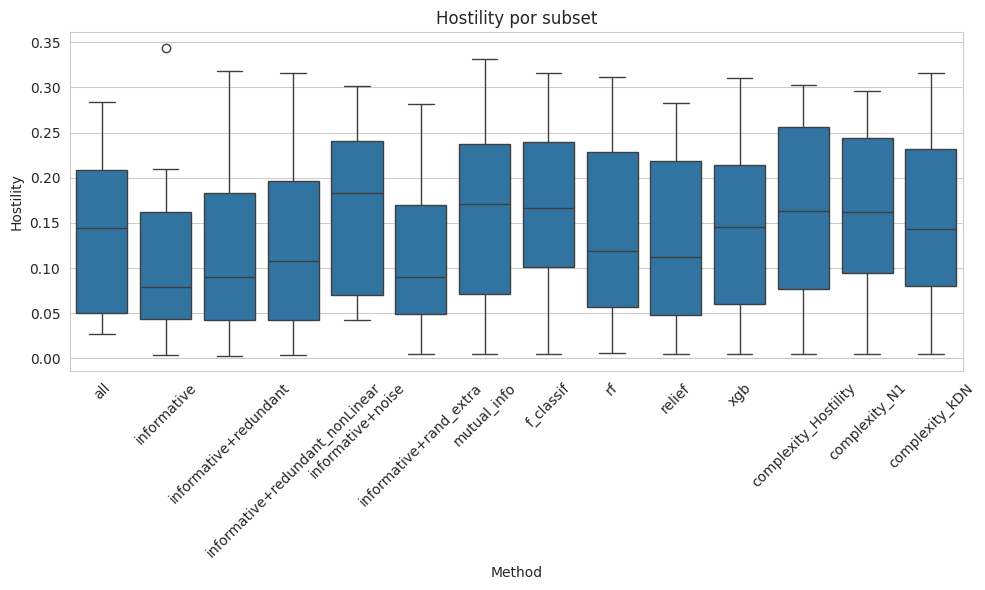

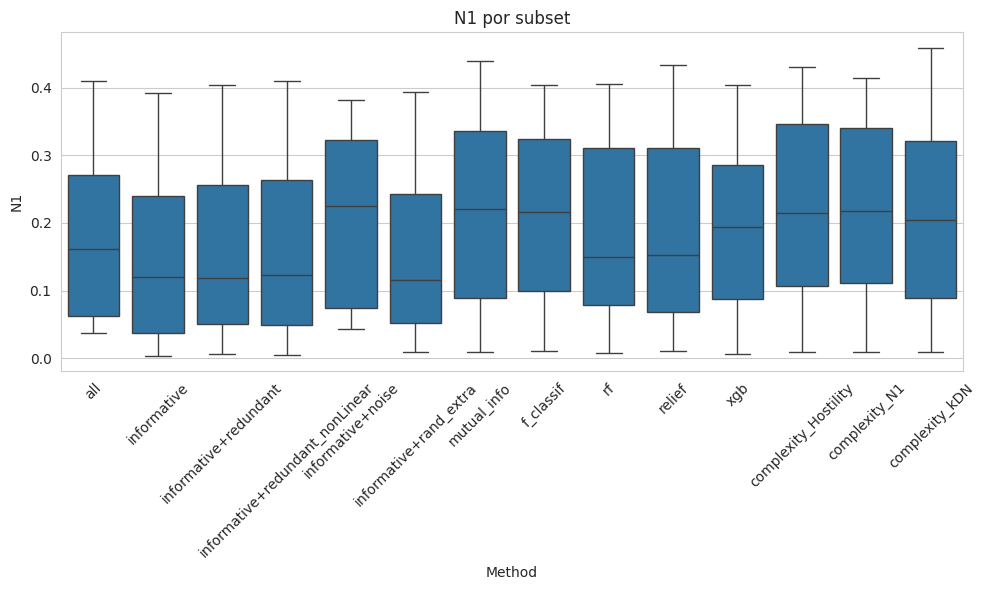

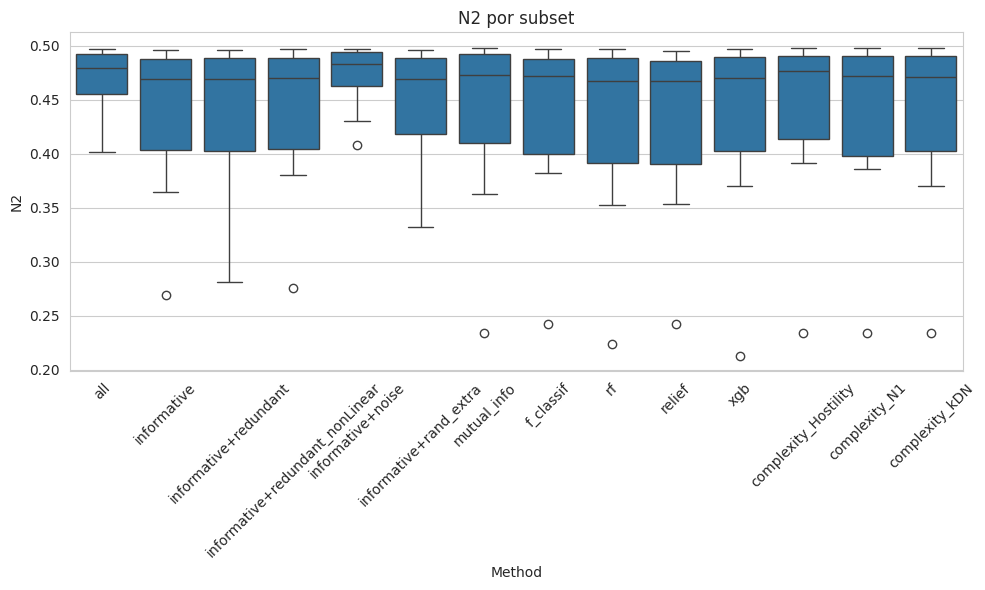

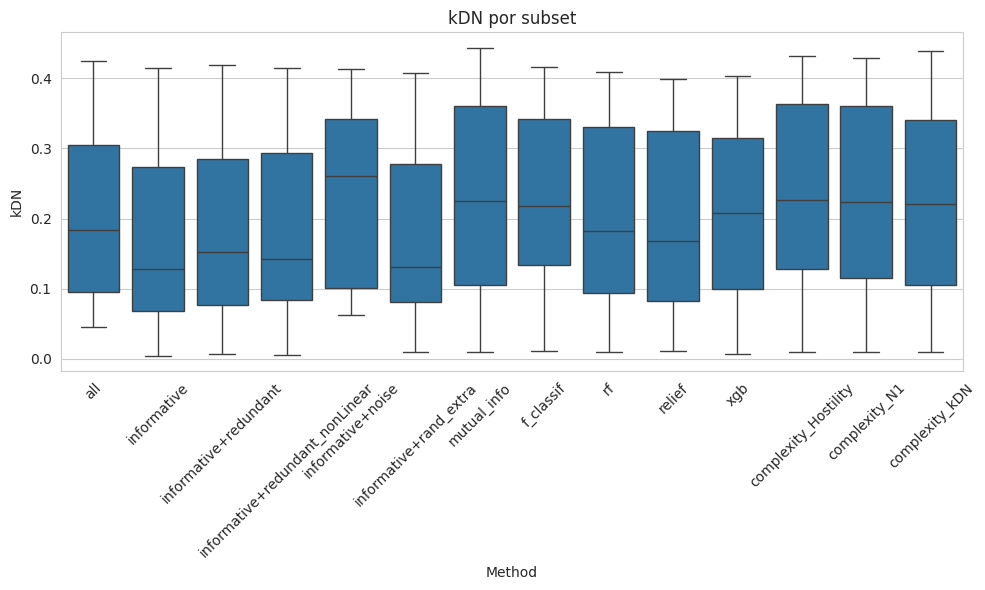

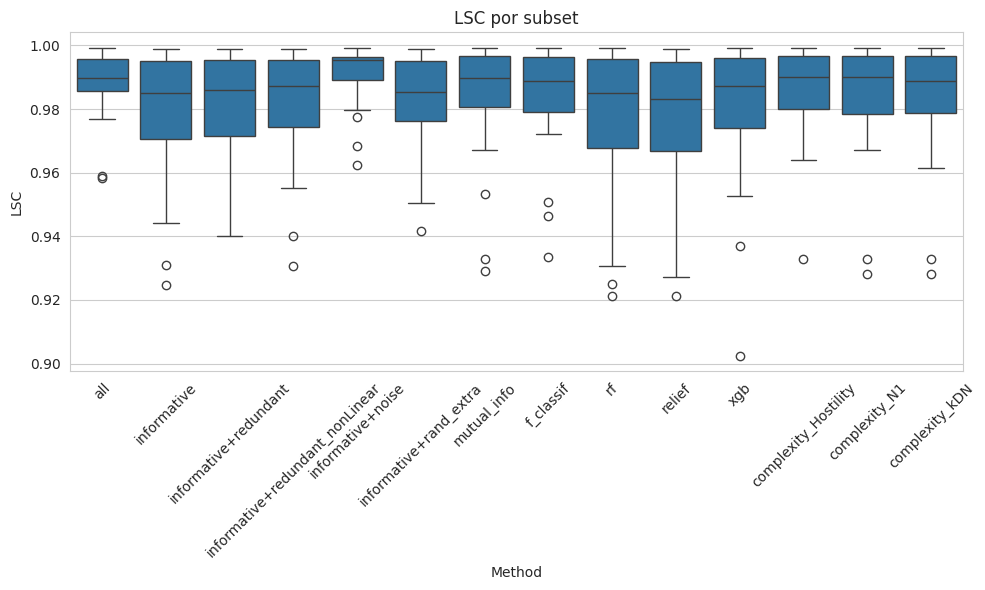

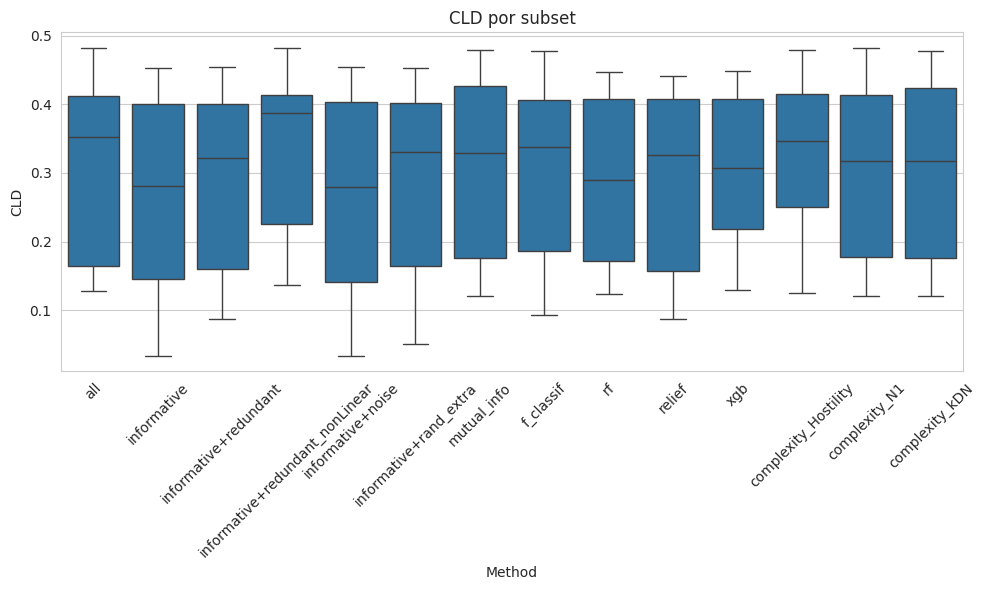

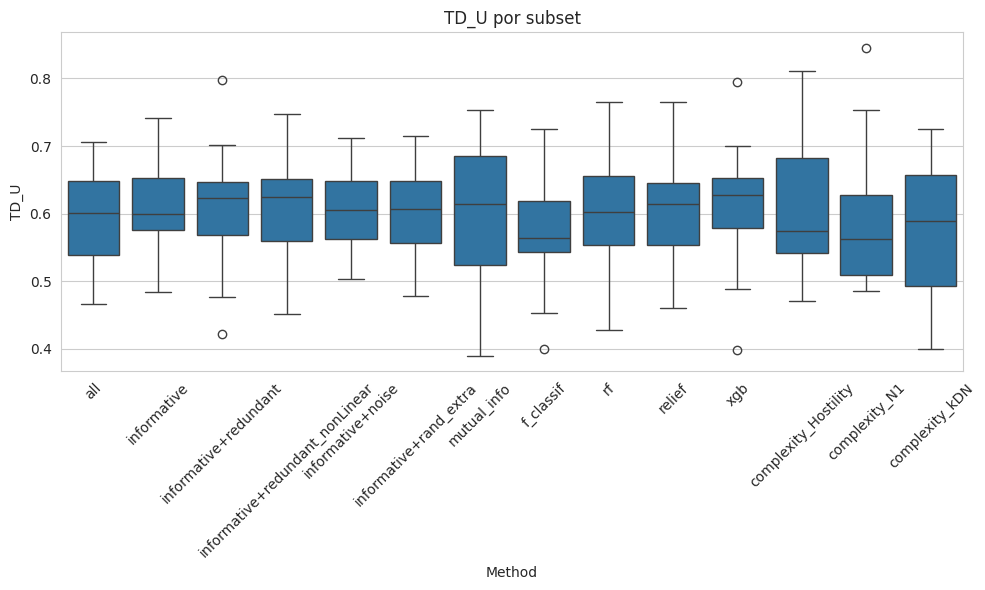

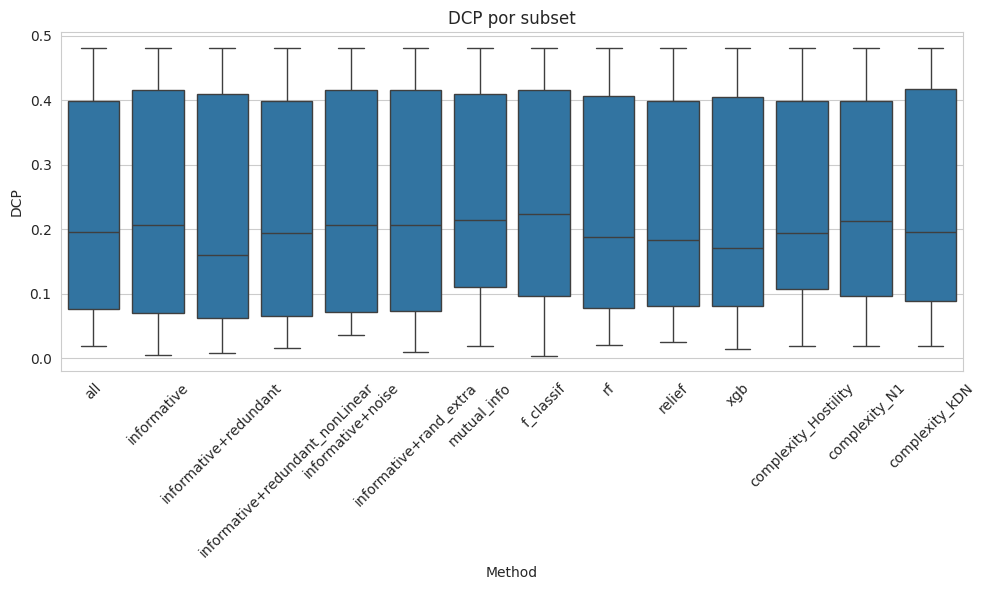

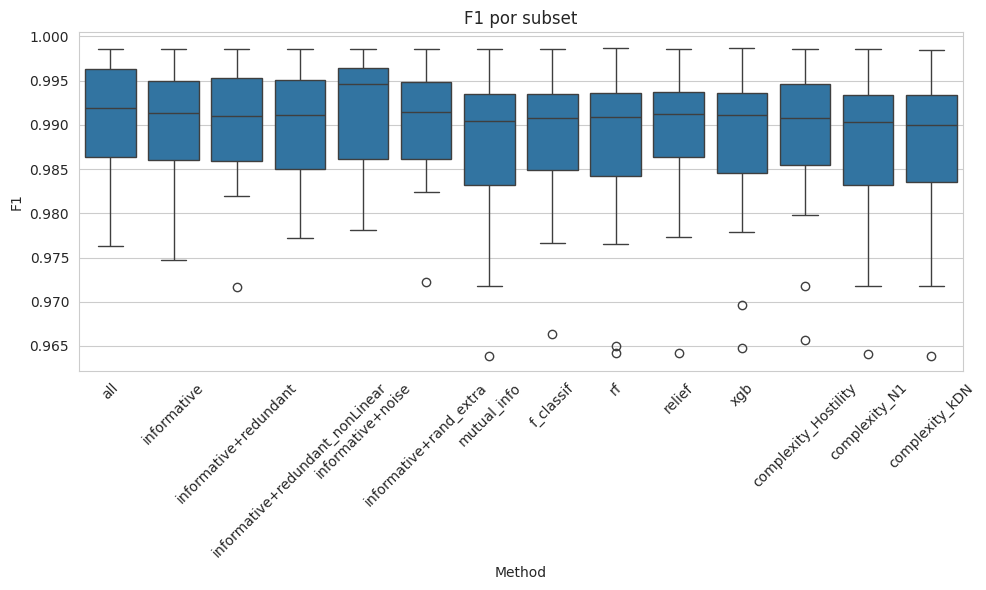

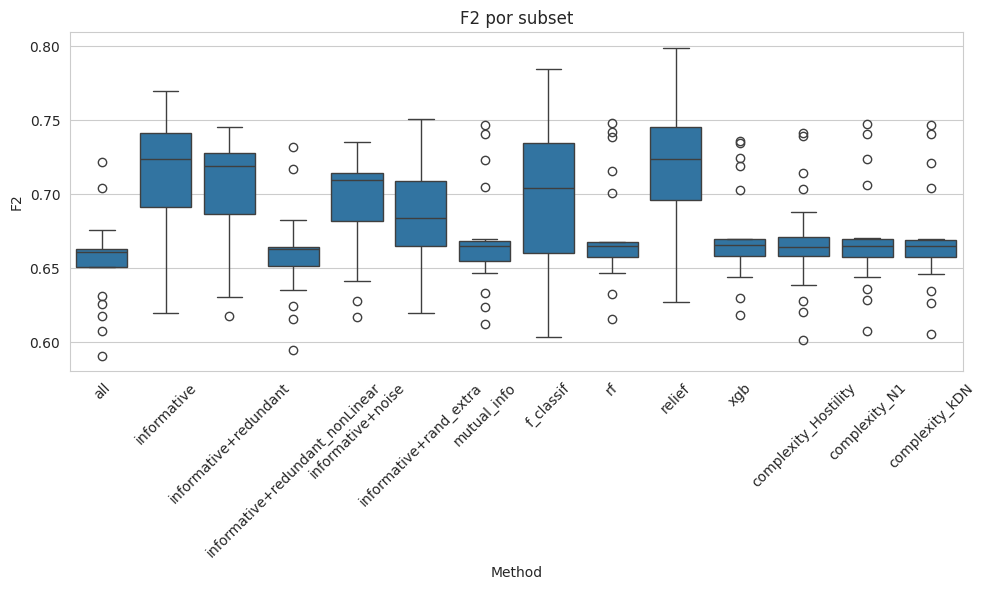

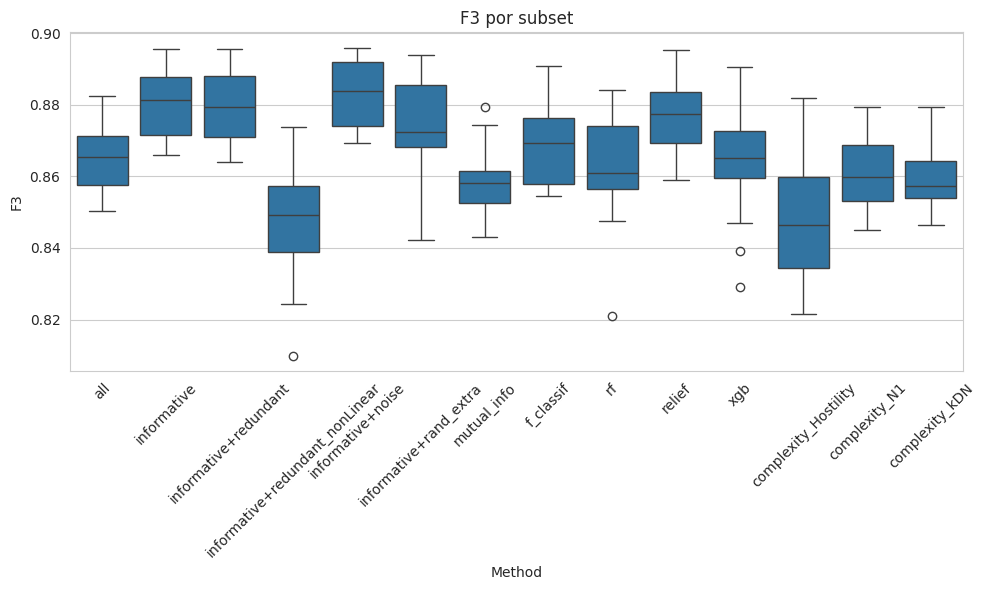

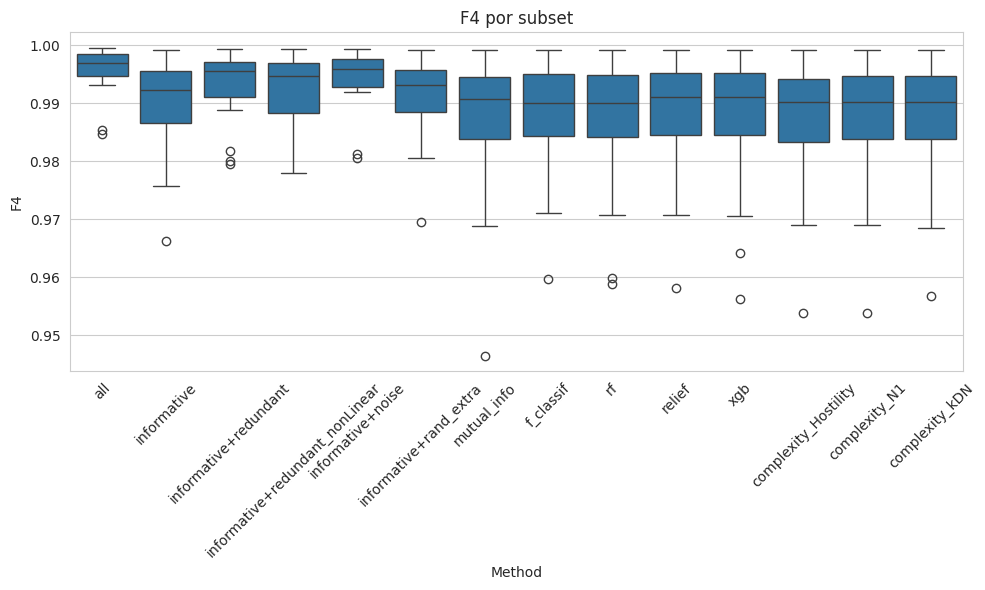

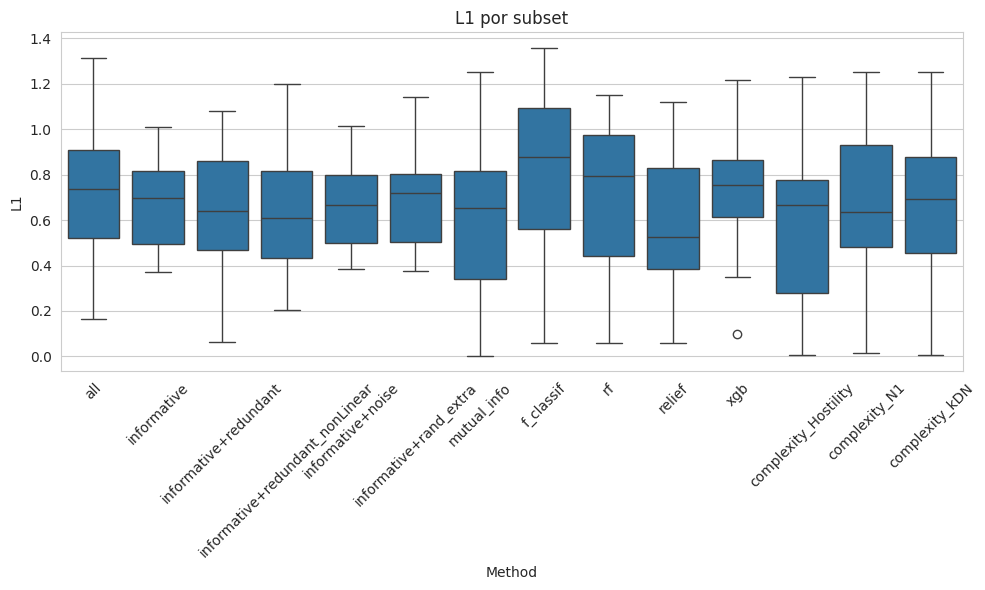

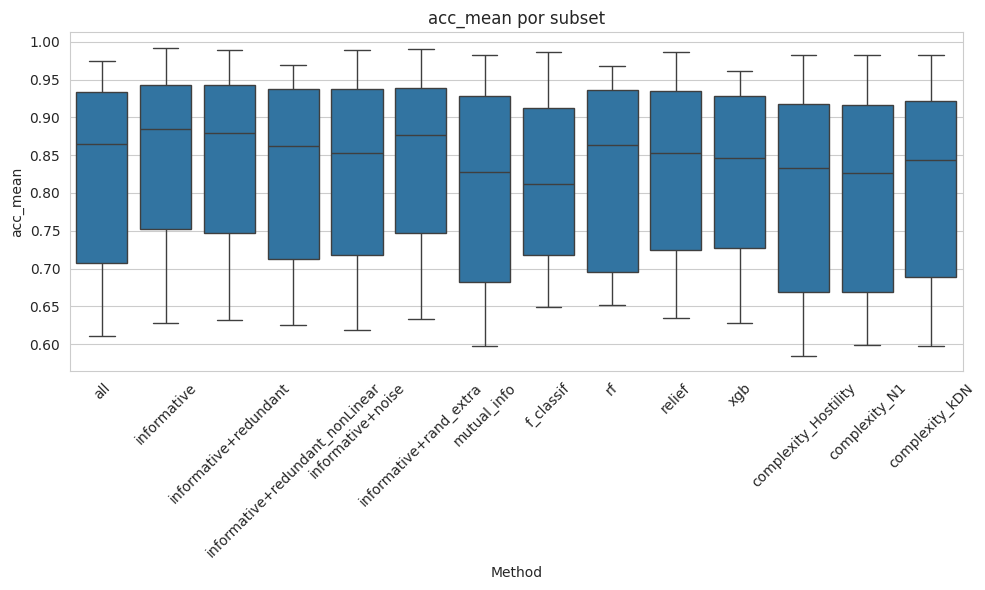

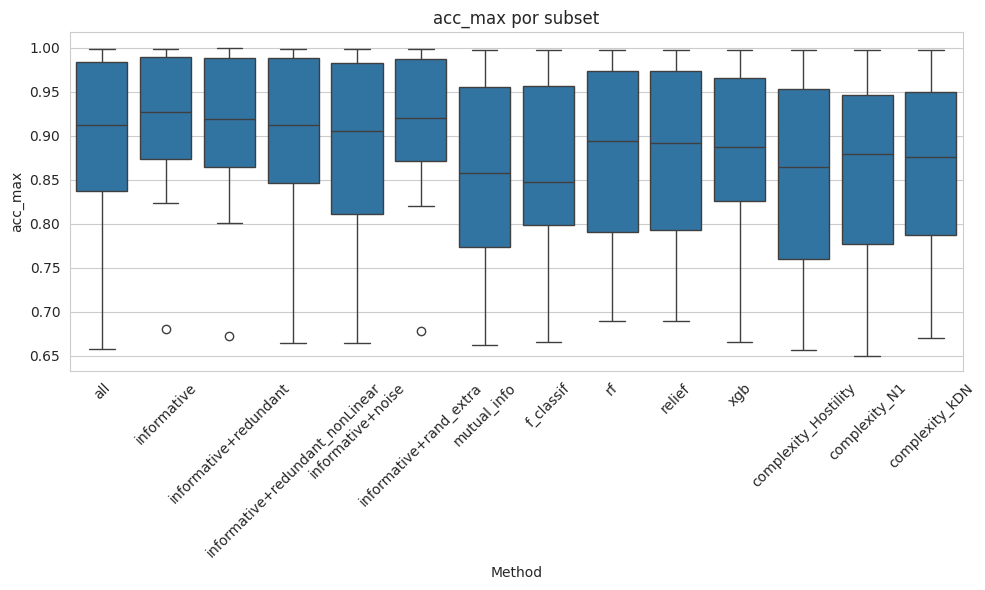

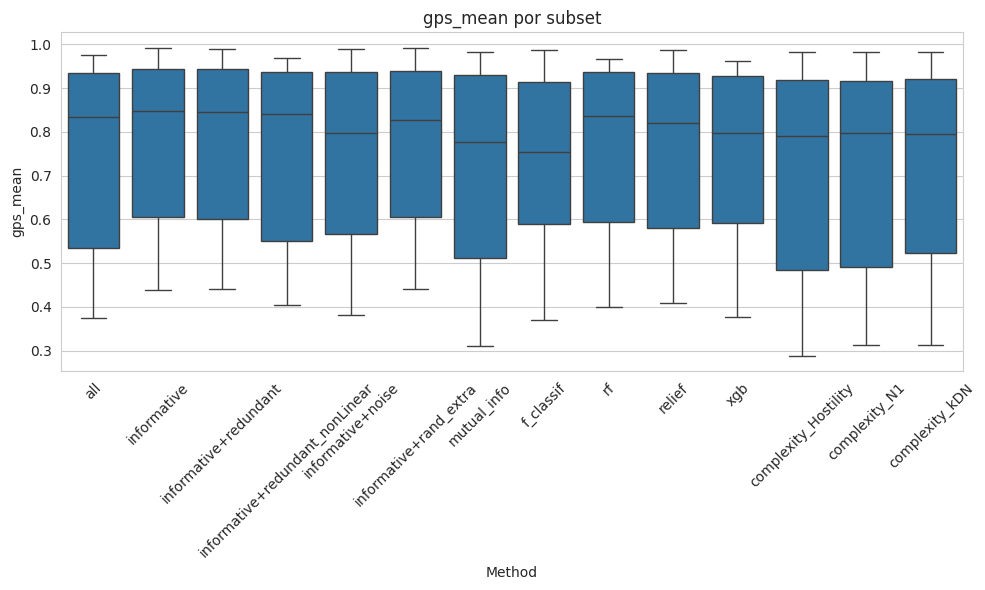

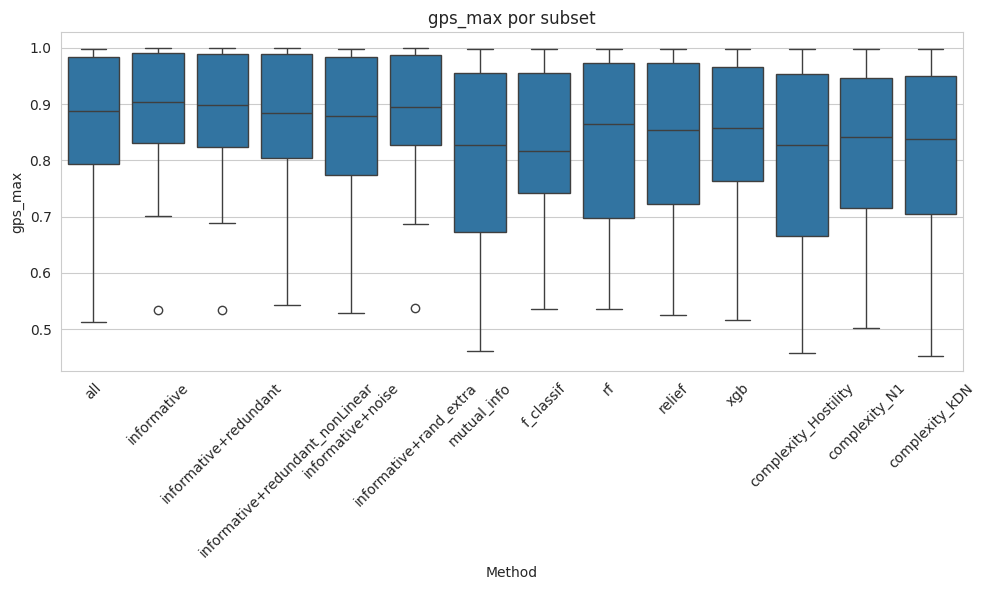

In [33]:
for measure in ["Hostility","N1","N2","kDN","LSC","CLD","TD_U","DCP","F1","F2","F3","F4","L1","acc_mean","acc_max",'gps_mean','gps_max']:
    plot_boxplots(combined, measure)
    # plot_boxplots(combined, measure, savepath=f"boxplot_{measure}.png")

## Conclusiones generales

Las medidas que mejor funcionan son claramente: Hostility, N1 y kDN. Obtienen menor media, mediana y std para el conjunto informativo real de variables. Aunque es verdad que a veces la complejidad del subconjunto realmente informativo y del informativo + algún tipo de redundancia es similar.
Hostility y N1 (se basa en MST, hay un paper que hace FS aplicando clustering con MST) tienen un mayor coste computacional que kDN. El resto de medidas están un poco perdidas.

Vemos que estas medidas sí son capaces de identificar que el conjunto de variables informativas tiene una complejidad menor que el resto de subconjuntos. Ojo porque todas son medidas de neighborhood, no son de Feature. Esto es interesante porque no están enfocadas en eso, pero revela que detectan bien la estructura de los datos y la interrelación entre las clases.

Otra observación interesante es que ninguno de los métodos de filtro de FS del SOTA probados  logran una complejidad similar a la del subconjunto realmente informativo. RelieF y RF son los que mejores valores de complejidad (en el sentido de aproximarse a los valores de complejidad logrados por el subconjunto realmente informativo). Los  boxplots de accuracy y gps que arrojan muestran mucha varianza y un rango mayor que el que se logra con todas las variables.


El filtro univariante con las medidas de complejidad funciona fatal. Seleccionan un subconjunto de variables que tiene una complejidad mayor que la del total de los datos a veces. Es más alta que la complejidad de los susbsets que eligen los métodos del SOTA --> Claramente el enfoque de evaluación de complejidad univariante y ranking no es bueno. Tiene sentido porque realmente lo que hemos visto hasta ahora es que lo pilla de forma multivariante, es decir, cuando las evalúa juntas.

Siguientes pasos:

   - Evaluar la complejidad a nivel instancia de las variables para ver si podemos sacar correlación o algo así. En mi cabeza cuadra que las variables redundantes otorguen una complejidad a nivel instancia similar y entonces deberíamos poder pillarlo. No es lo mismo correlación entre variables que correlación entre la complejidad de las instancias otorgadas por distintas variables.
   - Probar enfoque multivariante:
      - Como ya tenemos un ranking, ir metiendo en el orden del ranking (en plan forward selection) y parar cuando la disminución de complejidad no merezca la pena.
      - Con el mismo ranking, también podríamos empezar con todas e ir hacia atrás, aunque lo veo más problemático.
   - Con la información de complejidad a nivel instancia que tenemos, hacer traspuesta de datos. Entonces cada "variable" sería una instancia y cada instancia sería una variable. Con eso ya hemos reducido el problema de muchas variables (pues si tenemos muchas observaciones originales, tomamos una muestra y listo) y con eso hacer algún clustering para seleccionar representantes que, en este caso, serían  variables.
   - Probar idea de muestreo de variables para ir seleccionando.